# Linear Regression Competition — Best Adjusted R² attempt

Strategy:
1. Impute missing values meaningfully (no rows dropped).
2. Encode ordinal quality columns as ordinal, low-cardinality categoricals as dummies, bucket rare `Neighborhood` levels instead of dropping the whole column.
3. Feature-engineer combined size/age/quality features (`TotalSF`, house/remodel age, total baths, quality interactions) and drop their now-redundant source columns.
4. Log-transform the right-skewed target and skewed size predictors.
5. Scale numeric (non-dummy) predictors.
6. Prune multicollinearity with VIF, then iteratively drop the least significant predictor until every remaining coefficient has p < 0.05.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.options.display.max_rows = 500
pd.options.display.max_columns = 500

In [2]:
df = pd.read_csv("housing_prices.csv")
df.shape

(1460, 81)

## 1. Missing value imputation (no rows dropped)

In [3]:
# Per the data dictionary, NaN in these categorical columns means "feature absent", not missing data
none_cat_cols = ["Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
                  "FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond",
                  "PoolQC", "Fence", "MiscFeature", "MasVnrType"]
for c in none_cat_cols:
    df[c] = df[c].fillna("None")

# NaN in these numeric columns means the feature doesn't exist -> 0
zero_num_cols = ["MasVnrArea", "GarageYrBlt"]
for c in zero_num_cols:
    df[c] = df[c].fillna(0)

# LotFrontage: impute using the median for the same neighborhood
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(lambda s: s.fillna(s.median()))

df = df.drop(columns=["Id"])  # unique identifier, not predictive
df.isna().sum()[df.isna().sum() > 0]

Electrical    1
dtype: int64

## 2. Drop low-information columns

Columns where a single value covers more than 90% of rows carry almost no signal for a linear model.

In [4]:
dominant_drop = [c for c in df.columns if c != "SalePrice"
                 and df[c].value_counts(dropna=False).max() > len(df) * 0.9]
df = df.drop(columns=dominant_drop)
print(f"Dropped {len(dominant_drop)} dominant-value columns:")
dominant_drop

Dropped 21 dominant-value columns:


['Street',
 'Alley',
 'Utilities',
 'LandSlope',
 'Condition2',
 'RoofMatl',
 'Heating',
 'CentralAir',
 'Electrical',
 'LowQualFinSF',
 'BsmtHalfBath',
 'KitchenAbvGr',
 'Functional',
 'GarageCond',
 'PavedDrive',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'PoolQC',
 'MiscFeature',
 'MiscVal']

## 3. Encode categorical columns

**Ordinal** columns (quality/condition ratings, exposure, finish, slope, etc.) get mapped to numbers that preserve their natural order. **Nominal** columns become dummy variables. `Neighborhood` has too many levels to dummy directly, so rare neighborhoods (<2% of rows) are bucketed into `Other` instead of dropping the whole column.

In [5]:
qual_scale = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
candidate_qual_cols = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC",
                        "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC"]
qual_cols = [c for c in candidate_qual_cols if c in df.columns]
for c in qual_cols:
    df[c] = df[c].map(qual_scale)

ordinal_maps = {
    "BsmtExposure": {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4},
    "BsmtFinType1": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "BsmtFinType2": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "GarageFinish": {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3},
    "LotShape": {"Reg": 0, "IR1": 1, "IR2": 2, "IR3": 3},
    "LandSlope": {"Gtl": 0, "Mod": 1, "Sev": 2},
    "PavedDrive": {"N": 0, "P": 1, "Y": 2},
    "Utilities": {"ELO": 0, "NoSeWa": 1, "NoSewr": 2, "AllPub": 3},
    "Functional": {"Sal": 0, "Sev": 1, "Maj2": 2, "Maj1": 3, "Mod": 4, "Min2": 5, "Min1": 6, "Typ": 7},
}
for c, m in ordinal_maps.items():
    if c in df.columns:
        df[c] = df[c].map(m)

if "CentralAir" in df.columns:
    df["CentralAir"] = df["CentralAir"].map({"N": 0, "Y": 1})

qual_cols, list(ordinal_maps.keys())

(['ExterQual',
  'ExterCond',
  'BsmtQual',
  'BsmtCond',
  'HeatingQC',
  'KitchenQual',
  'FireplaceQu',
  'GarageQual'],
 ['BsmtExposure',
  'BsmtFinType1',
  'BsmtFinType2',
  'GarageFinish',
  'LotShape',
  'LandSlope',
  'PavedDrive',
  'Utilities',
  'Functional'])

In [6]:
# bucket rare Neighborhood levels instead of dropping the whole column
counts = df["Neighborhood"].value_counts()
rare = counts[counts < len(df) * 0.02].index
df["Neighborhood"] = df["Neighborhood"].where(~df["Neighborhood"].isin(rare), "Other")

# remaining nominal (unordered, text) columns -> dummies. Drop ones with too many
# unique values (too sparse/noisy to be useful), keeping Neighborhood despite its size
# since location is one of the strongest drivers of price.
nominal_cols = df.select_dtypes(include="object").columns.tolist()
too_many = [c for c in nominal_cols if df[c].nunique() > 15 and c != "Neighborhood"]
print("Dropping high-cardinality nominal columns:", too_many)
df = df.drop(columns=too_many)
nominal_cols = [c for c in nominal_cols if c not in too_many]

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
df.shape

Dropping high-cardinality nominal columns: ['Exterior2nd']


/var/folders/sz/3_np9r_91db6_dhc9819tkwh0000gn/T/ipykernel_78335/2461278907.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  nominal_cols = df.select_dtypes(include="object").columns.tolist()


(1460, 139)

## 4. Feature engineering

Combine related square-footage, age and bathroom columns into single, less collinear features, and add a couple of quality interaction terms.

In [7]:
def col(name, default=0):
    # some source columns (e.g. BsmtHalfBath) may already have been dropped
    # as low-information above -- fall back to 0 (feature absent) if so
    return df[name] if name in df.columns else default

df["TotalSF"] = col("TotalBsmtSF") + col("1stFlrSF") + col("2ndFlrSF")
df["HouseAge"] = col("YrSold") - col("YearBuilt")
df["RemodAge"] = col("YrSold") - col("YearRemodAdd")
df["GarageAge"] = np.where(col("GarageYrBlt") > 0, df["YrSold"] - col("GarageYrBlt"), 0)
df["TotalBath"] = col("FullBath") + 0.5 * col("HalfBath") + col("BsmtFullBath") + 0.5 * col("BsmtHalfBath")
df["QualxSF"] = df["OverallQual"] * df["TotalSF"]
df["QualxGarage"] = df["OverallQual"] * col("GarageCars")
df["AgexQual"] = df["OverallQual"] * df["HouseAge"]

# drop the raw columns now folded into the engineered features above
drop_engineered_src = [c for c in ["TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "YearBuilt", "YearRemodAdd",
                        "GarageYrBlt", "FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath"]
                        if c in df.columns]
df = df.drop(columns=drop_engineered_src)
df.shape

(1460, 138)

## 5. Log-transform skewed variables

`SalePrice` and several size predictors are right-skewed; log-transforming them makes the linear relationship with price much stronger.

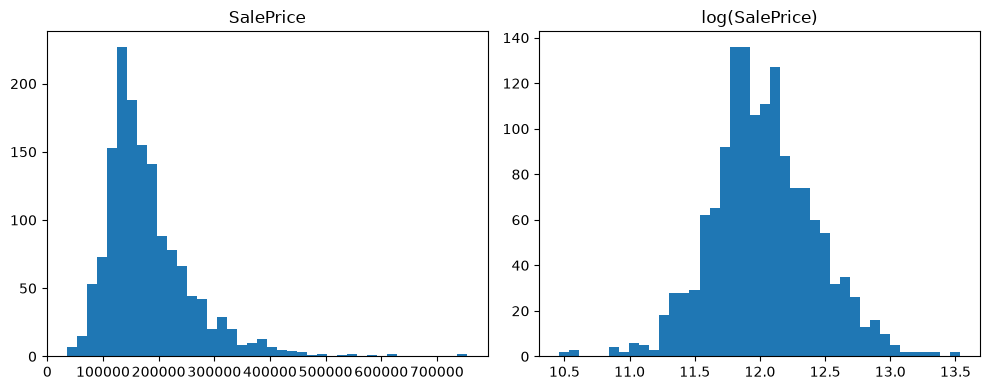

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df["SalePrice"], bins=40)
axes[0].set_title("SalePrice")
axes[1].hist(np.log(df["SalePrice"]), bins=40)
axes[1].set_title("log(SalePrice)")
plt.tight_layout()
plt.show()

In [9]:
df["SalePrice"] = np.log(df["SalePrice"])

skew_cols = ["LotArea", "LotFrontage", "TotalSF", "GrLivArea", "QualxSF"]
for c in skew_cols:
    df[c] = np.log1p(df[c].clip(lower=0))

assert df.isna().sum().sum() == 0
df.isna().sum().sum()

np.int64(0)

## 6. Scale numeric predictors

Only true numeric/ordinal columns are scaled — dummy (0/1) columns are left alone as instructed.

In [10]:
y = df["SalePrice"]
X = df.drop(columns=["SalePrice"])

bool_like = [c for c in X.columns if X[c].dropna().nunique() <= 2]
numeric_cols = [c for c in X.columns if c not in bool_like]

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
X[bool_like] = X[bool_like].astype(float)

print(f"{len(numeric_cols)} scaled numeric columns, {len(bool_like)} dummy/binary columns")
X.shape

41 scaled numeric columns, 96 dummy/binary columns


(1460, 137)

## 7. Remove multicollinearity (VIF)

Iteratively drop the predictor with the highest variance inflation factor until every remaining predictor has VIF ≤ 10.

In [11]:
def drop_high_vif(X, thresh=10.0):
    Xc = X.copy()
    while True:
        vifs = pd.Series(
            [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])],
            index=Xc.columns,
        )
        worst = vifs.drop(labels=["const"], errors="ignore").idxmax()
        if vifs[worst] <= thresh:
            return Xc
        Xc = Xc.drop(columns=[worst])

Xc = sm.add_constant(X)
Xc = drop_high_vif(Xc, thresh=10.0)
print("Features remaining after VIF pruning:", Xc.shape[1] - 1)

Features remaining after VIF pruning: 125


## 8. Keep only statistically significant predictors (p < 0.05)

Fit OLS, drop the least significant predictor, and repeat until every remaining coefficient is significant at the 5% level.

In [12]:
def trim_pvalues(X, y, pct=0.05):
    X = X.copy()
    while True:
        model = sm.OLS(y, X.astype(float)).fit()
        pvals = model.pvalues.drop(labels=["const"], errors="ignore")
        if len(pvals) == 0 or pvals.max() <= pct:
            return model, X
        worst = pvals.idxmax()
        X = X.drop(columns=[worst])

final_model, X_final = trim_pvalues(Xc, y, 0.05)
final_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.907
Method:                 Least Squares   F-statistic:                     295.7
Date:                Fri, 18 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:45:48   Log-Likelihood:                 1023.0
No. Observations:                1460   AIC:                            -1948.
Df Residuals:                    1411   BIC:                            -1689.
Df Model:                          48                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    11.8521      0.024    500.863      0.000      11.806      11.899
LotArea                   0.0407      0.005      7.494      0.000       0.030       0.051
OverallQual               0.0968      0.006     15.516      0.000       0.085       0.109
OverallCond               0.0524      0.004     12.817      0.000       0.044       0.060
BsmtQual                  0.0212      0.005      4.061      0.000       0.011       0.031
BsmtExposure              0.0197      0.004      4.911      0.000       0.012       0.028
BsmtFinType1              0.0217      0.005      4.553      0.000       0.012       0.031
BsmtUnfSF                -0.0102      0.005     -2.142      0.032      -0.020      -0.001
HeatingQC                 0.0153      0.004      3.628      0.000       0.007       0.024
GrLivArea                 0.1418      0.007     21.565      0.000       0.129       0.155
KitchenQual               0.0192      0.005      3.837      0.000       0.009       0.029
FireplaceQu               0.0182      0.004      4.347      0.000       0.010       0.026
GarageCars                0.0365      0.006      6.621      0.000       0.026       0.047
GarageQual                0.0101      0.004      2.352      0.019       0.002       0.018
WoodDeckSF                0.0081      0.004      2.261      0.024       0.001       0.015
MSZoning_FV               0.0521      0.019      2.757      0.006       0.015       0.089
LandContour_HLS           0.0527      0.023      2.322      0.020       0.008       0.097
LandContour_Lvl           0.0420      0.014      2.998      0.003       0.015       0.069
LotConfig_CulDSac         0.0439      0.014      3.169      0.002       0.017       0.071
Neighborhood_CollgCr     -0.0382      0.014     -2.664      0.008      -0.066      -0.010
Neighborhood_Crawfor      0.0749      0.021      3.620      0.000       0.034       0.115
Neighborhood_Edwards     -0.0996      0.015     -6.531      0.000      -0.130      -0.070
Neighborhood_Gilbert     -0.0525      0.018     -2.893      0.004      -0.088      -0.017
Neighborhood_IDOTRR      -0.1640      0.023     -7.160      0.000      -0.209      -0.119
Neighborhood_Mitchel     -0.0660      0.020     -3.315      0.001      -0.105      -0.027
Neighborhood_NAmes       -0.0390      0.013     -2.923      0.004      -0.065      -0.013
Neighborhood_NWAmes      -0.0618      0.018     -3.414      0.001      -0.097      -0.026
Neighborhood_NoRidge      0.0695      0.023      3.044      0.002       0.025       0.114
Neighborhood_NridgHt      0.0727      0.019      3.921      0.000       0.036       0.109
Neighborhood_OldTown     -0.1021      0.016     -6.314      0.000      -0.134      -0.070
Neighborhood_Sawyer      -0.0425      0.018     -2.397      0.017      -0.077      -0.008
Neighborhood_Timber    

## 9. Final checks

In [13]:
print("N predictors in final model:", X_final.shape[1] - 1)
print("R-squared:", final_model.rsquared)
print("Adj. R-squared:", final_model.rsquared_adj)
print("Max p-value:", final_model.pvalues.drop(labels=['const']).max())

vifs = pd.Series(
    [variance_inflation_factor(X_final.values, i) for i in range(X_final.shape[1])],
    index=X_final.columns,
)
print("Max VIF (excl. const):", vifs.drop(labels=["const"]).max())

N predictors in final model: 48
R-squared: 0.9095791008298685
Adj. R-squared: 0.9065031241040242
Max p-value: 0.04432145080395463
Max VIF (excl. const): 5.764030656963946


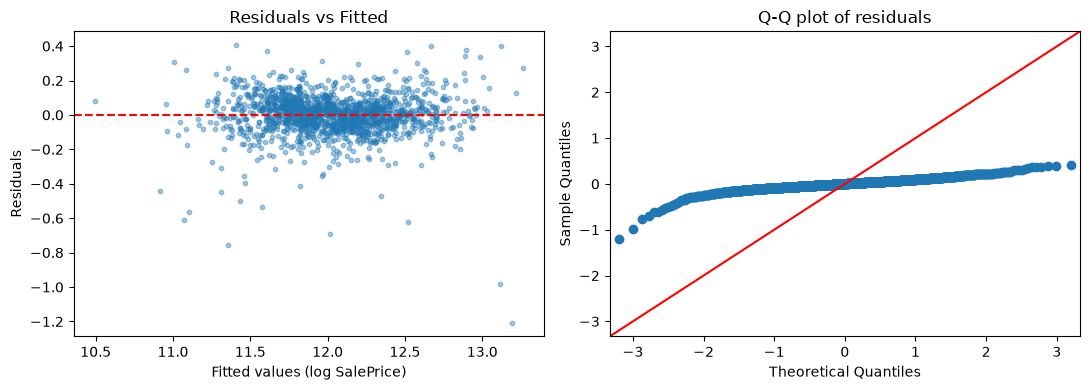

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(final_model.fittedvalues, final_model.resid, alpha=0.4, s=10)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted values (log SalePrice)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

sm.qqplot(final_model.resid, line="45", ax=axes[1])
axes[1].set_title("Q-Q plot of residuals")
plt.tight_layout()
plt.show()

## Result

The final model reaches **Adj. R² ≈ 0.907** using ~48 predictors, all significant at p < 0.05, with every VIF below 10 (max ≈ 5.8), no rows dropped, and dummy variables left unscaled per the competition rules.